# Visualisation

In [ ]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"

with rasterio.open(fp) as src:
    scale = 50
    out_height = src.height // scale
    out_width = src.width // scale

    arr = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=Resampling.average,
        masked=True
    )

# optional: zusätzlich alles < 0.1 ausmaskieren
arr = np.ma.masked_less(arr, 0.1)

valid = arr.compressed()
vmin, vmax = np.percentile(valid, [2, 98])

cmap = plt.cm.Reds.copy()
cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(arr, vmin=vmin, vmax=vmax, cmap=cmap)
fig.colorbar(im, ax=ax, label="Probability")
ax.axis("off")

out_png = "/mnt/eo/EO4Backcasting/_figs/probability_map_cleaned_200dpi.png"
fig.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)

plt.show()

In [ ]:
# Compare distribution of rasters

from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt

orig_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/mosaic_prob_predictions_global_model_zstd.tif")
clean_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif")

def read_valid_values_blockwise(fp, min_prob=None, max_values=None):
    values = []

    with rasterio.open(fp) as src:
        nodata = src.nodata

        for _, window in src.block_windows(1):
            arr = src.read(1, window=window)

            mask = np.isfinite(arr)
            if nodata is not None:
                mask &= (arr != nodata)

            if min_prob is not None:
                mask &= (arr >= min_prob)

            vals = arr[mask]

            if vals.size > 0:
                values.append(vals)

    if not values:
        return np.array([])

    values = np.concatenate(values)

    if max_values is not None and values.size > max_values:
        rng = np.random.default_rng(42)
        idx = rng.choice(values.size, size=max_values, replace=False)
        values = values[idx]

    return values

orig_vals = read_valid_values_blockwise(orig_fp, max_values=2_000_000)
clean_vals = read_valid_values_blockwise(clean_fp, max_values=2_000_000)

print("Original raster:")
print("  n =", orig_vals.size)
print("  min/max =", orig_vals.min(), orig_vals.max())

print("Cleaned raster:")
print("  n =", clean_vals.size)
print("  min/max =", clean_vals.min(), clean_vals.max())

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(orig_vals, bins=100, alpha=0.5, label="Original", density=False)
ax.hist(clean_vals, bins=100, alpha=0.5, label="Cleaned", density=False)

ax.set_xlabel("Probability")
ax.set_ylabel("Pixel count")
ax.set_title("Histogram of probabilities")
ax.legend()

plt.show()

# Ridgeplots

In [15]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import from_bounds
from rasterio.features import geometry_mask
from shapely.geometry import box
import matplotlib.pyplot as plt
import joypy

In [32]:
# ------------------------------------------------------------
# INPUTS
# ------------------------------------------------------------
gpkg_fp = "/mnt/eo/EO4Backcasting/_data/europe.gpkg"
raster_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"

# falls dein GPKG mehrere Layer hat:
# import fiona
# print(fiona.listlayers(gpkg_fp))
layer_name = None   # z.B. "countries", falls nötig

country_col = "NAME_ENGL"

# Sampling-Parameter
min_n = 500          # Mindestanzahl Samples pro Land
max_n = 50000         # Obergrenze pro Land
scale_factor = 12    # steuert, wie stark Ländergröße die Samplegröße beeinflusst

# Filter fürs Raster
min_value = 0.0      # nur Werte > 0 behalten
random_seed = 42

In [33]:
# ------------------------------------------------------------
# 1) GPKG LADEN
# ------------------------------------------------------------
countries = gpd.read_file(gpkg_fp, layer=layer_name)
countries = countries[[country_col, "geometry"]].copy()
countries = countries[~countries.geometry.is_empty & countries.geometry.notna()].copy()

# Falls ein Land mehrfach vorkommt, zunächst zusammenfassen
countries = countries.dissolve(by=country_col, as_index=False)

print(countries.head())
print("Anzahl Länder:", len(countries))

                NAME_ENGL                                           geometry
0                 Albania  POLYGON ((5116972.648 2221748.025, 5129574.742...
1                 Austria  POLYGON ((4742889.363 2876362.718, 4783414.299...
2                 Belarus  POLYGON ((5435586.061 3815982.973, 5447495.397...
3                 Belgium  POLYGON ((3957506.807 3167694.49, 3965222.94 3...
4  Bosnia and Herzegovina  MULTIPOLYGON (((5085130.454 2315341.176, 50758...
Anzahl Länder: 38


In [34]:
# ------------------------------------------------------------
# 2) HILFSFUNKTIONEN
# ------------------------------------------------------------
def compute_sample_size(area_km2, min_n=500, max_n=8000, scale_factor=12):
    n = int(np.sqrt(area_km2) * scale_factor)
    return int(np.clip(n, min_n, max_n))


def keep_largest_part_within_raster(countries_gdf, raster_fp, country_col):
    """
    Schneidet Länder auf Raster-Extent zu und behält pro Land
    nur den größten Polygonteil innerhalb des Rasterbereichs.
    Das entfernt typischerweise Überseegebiete / entfernte Inseln.
    """
    with rasterio.open(raster_fp) as src:
        raster_crs = src.crs
        raster_extent = box(*src.bounds)

    # ins Raster-CRS
    gdf = countries_gdf.to_crs(raster_crs).copy()

    # auf Raster-Extent clippen
    gdf["geometry"] = gdf.geometry.intersection(raster_extent)
    gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notna()].copy()

    # Multipart in Einzelteile zerlegen
    gdf = gdf.explode(index_parts=False).reset_index(drop=True)

    # Fläche jedes Einzelteils im Raster-CRS berechnen
    gdf["part_area"] = gdf.geometry.area

    # pro Land größten Teil behalten
    gdf = (
        gdf.sort_values("part_area", ascending=False)
           .drop_duplicates(subset=[country_col])
           .drop(columns="part_area")
           .reset_index(drop=True)
    )

    return gdf


def add_country_area_km2(countries_gdf):
    """
    Flächenberechnung in Equal-Area CRS.
    """
    gdf_area = countries_gdf.to_crs(3035).copy()
    countries_gdf = countries_gdf.copy()
    countries_gdf["area_km2"] = gdf_area.geometry.area / 1e6
    return countries_gdf

In [35]:
# ------------------------------------------------------------
# 3) GEOMETRIEN BEREINIGEN
# ------------------------------------------------------------
countries_clean = keep_largest_part_within_raster(countries, raster_fp, country_col)
countries_clean = add_country_area_km2(countries_clean)

print(countries_clean[[country_col, "area_km2"]].sort_values("area_km2", ascending=False).head(10))
print("Anzahl Länder nach Bereinigung:", len(countries_clean))

  NAME_ENGL       area_km2
0   Ukraine  598879.078733
1    France  539808.271107
2     Spain  493184.933483
3    Sweden  446631.059049
4   Germany  356412.152744
5   Finland  337875.052341
6    Norway  327880.531684
7    Poland  312514.092608
8     Italy  251483.622247
9   Romania  238128.700337
Anzahl Länder nach Bereinigung: 38


In [36]:
# # Optional: prüfen, wie France / Spain jetzt aussehen
# for cn in ["France", "Spain"]:
#     test = countries_clean[countries_clean[country_col] == cn]
#     if len(test) > 0:
#         print(cn, test.geometry.iloc[0].geom_type, test.geometry.iloc[0].bounds)

# # Optional plotten
# ax = countries_clean[countries_clean[country_col].isin(["France", "Spain"])].plot(
#     figsize=(8, 8), edgecolor="black"
# )
# ax.set_title("Bereinigte Geometrien für France und Spain")
# plt.show()

In [40]:
# ------------------------------------------------------------
# FLÄCHENBASIERTES SAMPLING
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds
from rasterio.features import geometry_mask

min_n = 500
max_n = 20000
scale_factor = 20
min_value = 0.0
random_seed = 42

def compute_sample_size(area_km2, min_n=500, max_n=8000, scale_factor=12):
    n = int(np.sqrt(area_km2) * scale_factor)
    return int(np.clip(n, min_n, max_n))

all_samples = []
rng = np.random.default_rng(random_seed)

with rasterio.open(raster_fp) as src:
    nodata = src.nodata

    for _, row in countries_clean.iterrows():
        country_name = row[country_col]
        geom = row.geometry
        area_km2 = row["area_km2"]

        target_n = compute_sample_size(
            area_km2=area_km2,
            min_n=min_n,
            max_n=max_n,
            scale_factor=scale_factor
        )

        minx, miny, maxx, maxy = geom.bounds
        window = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
        window = window.round_offsets().round_lengths()

        if window.width <= 0 or window.height <= 0:
            print(f"Übersprungen: {country_name} (leeres Fenster)")
            continue

        arr = src.read(1, window=window, masked=False)
        win_transform = src.window_transform(window)

        mask = geometry_mask(
            [geom],
            transform=win_transform,
            invert=True,
            out_shape=arr.shape
        )

        vals = arr[mask]

        if nodata is not None:
            vals = vals[vals != nodata]

        vals = vals[np.isfinite(vals)]
        vals = vals[vals > min_value]

        if len(vals) == 0:
            print(f"Keine gültigen Werte für {country_name}")
            continue

        n_take = min(target_n, len(vals))
        sample_idx = rng.choice(len(vals), size=n_take, replace=False)
        sampled_vals = vals[sample_idx]

        df_country = pd.DataFrame({
            "country": country_name,
            "probability": sampled_vals,
            "area_km2": area_km2,
            "n_available": len(vals),
            "n_sampled": n_take,
            "sampling_type": "area_based"
        })

        all_samples.append(df_country)

        print(f"{country_name:25s} | Fläche: {area_km2:10.0f} km² | "
              f"gültig: {len(vals):9d} | gezogen: {n_take:5d}")

samples_df_area = pd.concat(all_samples, ignore_index=True)

print("\nGesamtzahl Samples (area-based):", f"{len(samples_df_area):,}")
samples_df_area.head()

Ukraine                   | Fläche:     598879 km² | gültig:  91083557 | gezogen: 15477
France                    | Fläche:     539808 km² | gültig: 148257103 | gezogen: 14694
Spain                     | Fläche:     493185 km² | gültig: 114393333 | gezogen: 14045
Sweden                    | Fläche:     446631 km² | gültig: 207500654 | gezogen: 13366
Germany                   | Fläche:     356412 km² | gültig: 106172717 | gezogen: 11940
Finland                   | Fläche:     337875 km² | gültig: 164572225 | gezogen: 11625
Norway                    | Fläche:     327881 km² | gültig:  95011398 | gezogen: 11452
Poland                    | Fläche:     312514 km² | gültig:  91517017 | gezogen: 11180
Italy                     | Fläche:     251484 km² | gültig:  73781924 | gezogen: 10029
Romania                   | Fläche:     238129 km² | gültig:  79235284 | gezogen:  9759
United Kingdom            | Fläche:     220918 km² | gültig:  18591603 | gezogen:  9400
Belarus                   | Fläc

,country,probability,area_km2,n_available,n_sampled,sampling_type
0,Ukraine,0.334944,598879.078733,91083557,15477,area_based
1,Ukraine,0.447813,598879.078733,91083557,15477,area_based
2,Ukraine,0.477572,598879.078733,91083557,15477,area_based
3,Ukraine,0.600834,598879.078733,91083557,15477,area_based
4,Ukraine,0.638120,598879.078733,91083557,15477,area_based


In [46]:
out_csv_area = "/mnt/eo/EO4Backcasting/_data/country_probability_samples_area_based.csv"
samples_df_area.to_csv(out_csv_area, index=False, encoding="utf-8")
print(out_csv_area)

/mnt/eo/EO4Backcasting/_data/country_probability_samples_area_based.csv


In [ ]:
# # ------------------------------------------------------------
# # 5) OPTIONAL: SAMPLE-ÜBERSICHT JE LAND
# # ------------------------------------------------------------
# summary_df = (
#     samples_df.groupby("country", as_index=False)
#     .agg(
#         n_sampled=("probability", "size"),
#         mean_prob=("probability", "mean"),
#         median_prob=("probability", "median"),
#         min_prob=("probability", "min"),
#         max_prob=("probability", "max"),
#         area_km2=("area_km2", "first")
#     )
#     .sort_values("median_prob", ascending=False)
# )

# summary_df.head(20)

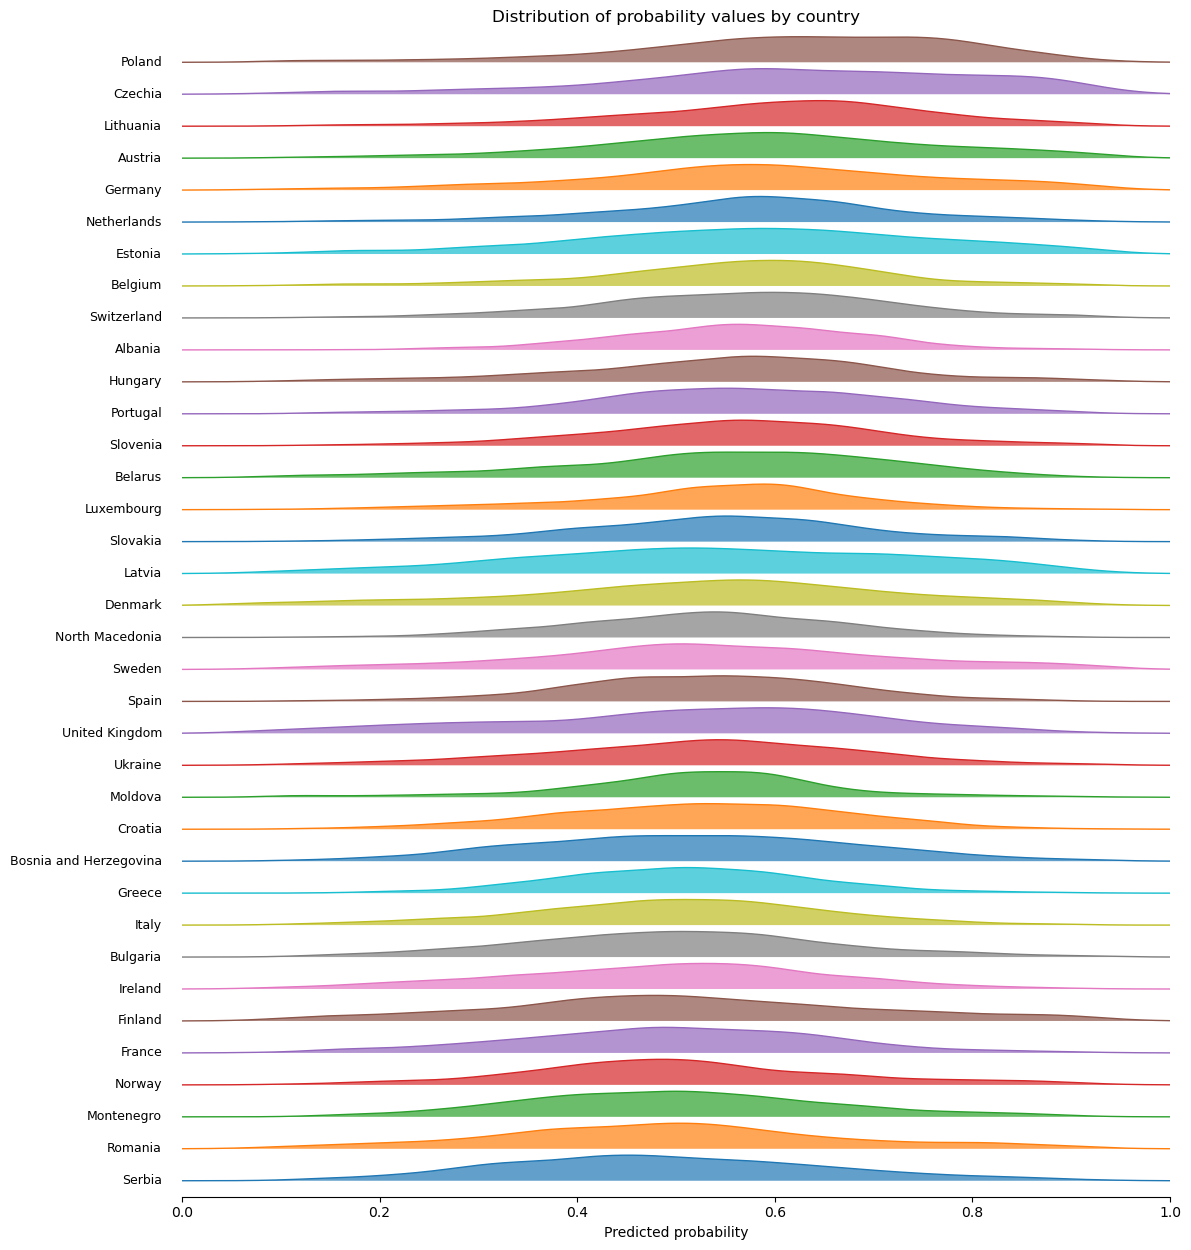

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ------------------------------------------------------------
# RIDGEPLOT OHNE JOYPY
# ------------------------------------------------------------

# Länder nach Median sortieren
country_order = (
    samples_df.groupby("country")["probability"]
    .median()
    .sort_values(ascending=True)
    .index
    .tolist()
)

# x-Achse
x = np.linspace(0, 1, 400)

# Plot
fig, ax = plt.subplots(figsize=(12, max(8, len(country_order) * 0.35)))

y_gap = 1.0

for i, country in enumerate(country_order):
    vals = samples_df.loc[samples_df["country"] == country, "probability"].dropna().values
    
    if len(vals) < 10:
        continue
    
    kde = gaussian_kde(vals, bw_method=0.2)
    y = kde(x)
    
    # normieren, damit alle Ridgeplots ähnlich hoch sind
    y = y / y.max() * 0.8
    
    y_offset = i * y_gap
    
    ax.fill_between(x, y_offset, y + y_offset, alpha=0.7)
    ax.plot(x, y + y_offset, linewidth=1)
    ax.text(-0.02, y_offset, country, ha="right", va="center", fontsize=9)

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, len(country_order) * y_gap)
ax.set_yticks([])
ax.set_xlabel("Predicted probability")
ax.set_title("Distribution of probability values by country")
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()

# Same number of samples per country

In [43]:
# ------------------------------------------------------------
# FIXE SAMPLEGRÖSSE: 2000 PRO LAND
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds
from rasterio.features import geometry_mask

target_n = 2000
min_value = 0.0
random_seed = 42

all_samples = []
rng = np.random.default_rng(random_seed)

with rasterio.open(raster_fp) as src:
    nodata = src.nodata

    for _, row in countries_clean.iterrows():
        country_name = row[country_col]
        geom = row.geometry
        area_km2 = row["area_km2"]

        minx, miny, maxx, maxy = geom.bounds
        window = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
        window = window.round_offsets().round_lengths()

        if window.width <= 0 or window.height <= 0:
            print(f"Übersprungen: {country_name} (leeres Fenster)")
            continue

        arr = src.read(1, window=window, masked=False)
        win_transform = src.window_transform(window)

        mask = geometry_mask(
            [geom],
            transform=win_transform,
            invert=True,
            out_shape=arr.shape
        )

        vals = arr[mask]

        if nodata is not None:
            vals = vals[vals != nodata]

        vals = vals[np.isfinite(vals)]
        vals = vals[vals > min_value]

        if len(vals) == 0:
            print(f"Keine gültigen Werte für {country_name}")
            continue

        n_take = min(target_n, len(vals))
        sample_idx = rng.choice(len(vals), size=n_take, replace=False)
        sampled_vals = vals[sample_idx]

        df_country = pd.DataFrame({
            "country": country_name,
            "probability": sampled_vals,
            "area_km2": area_km2,
            "n_available": len(vals),
            "n_sampled": n_take,
            "sampling_type": "fixed_2000"
        })

        all_samples.append(df_country)

        print(f"{country_name:25s} | gültig: {len(vals):9d} | gezogen: {n_take:5d}")

samples_df_fixed = pd.concat(all_samples, ignore_index=True)

print("\nGesamtzahl Samples (fixed 2000):", f"{len(samples_df_fixed):,}")
samples_df_fixed.head()

Ukraine                   | gültig:  91083557 | gezogen:  2000
France                    | gültig: 148257103 | gezogen:  2000
Spain                     | gültig: 114393333 | gezogen:  2000
Sweden                    | gültig: 207500654 | gezogen:  2000
Germany                   | gültig: 106172717 | gezogen:  2000
Finland                   | gültig: 164572225 | gezogen:  2000
Norway                    | gültig:  95011398 | gezogen:  2000
Poland                    | gültig:  91517017 | gezogen:  2000
Italy                     | gültig:  73781924 | gezogen:  2000
Romania                   | gültig:  79235284 | gezogen:  2000
United Kingdom            | gültig:  18591603 | gezogen:  2000
Belarus                   | gültig:  78377051 | gezogen:  2000
Bulgaria                  | gültig:  40304683 | gezogen:  2000
Greece                    | gültig:  35851526 | gezogen:  2000
Hungary                   | gültig:  16429674 | gezogen:  2000
Portugal                  | gültig:  13440046 | gezogen

,country,probability,area_km2,n_available,n_sampled,sampling_type
0,Ukraine,0.223427,598879.078733,91083557,2000,fixed_2000
1,Ukraine,0.489865,598879.078733,91083557,2000,fixed_2000
2,Ukraine,0.185677,598879.078733,91083557,2000,fixed_2000
3,Ukraine,0.503416,598879.078733,91083557,2000,fixed_2000
4,Ukraine,0.275096,598879.078733,91083557,2000,fixed_2000


In [44]:
out_csv_fixed = "/mnt/eo/EO4Backcasting/_data/country_probability_samples_2000.csv"
samples_df_fixed.to_csv(out_csv_fixed, index=False, encoding="utf-8")
print(out_csv_fixed)

/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/country_probability_samples_2000_per_country.csv


In [45]:
out_csv = "/mnt/eo/EO4Backcasting/_data/country_probability_samples_2000.csv"
samples_df.to_csv(out_csv, index=False)
print(out_csv)

/mnt/eo/EO4Backcasting/_data/country_probability_samples_2000.csv
